# 05 -- Statistics Deep Dive: Jaccard, Dice, Overlap, Enrichment, and BH-FDR

Every pairwise statistics table produced by `result.statistics` answers a subtly
different question. Picking the right metric prevents misleading conclusions:

- **Jaccard**: how much do two sets overlap relative to everything in either set?
- **Dice (Sorensen-Dice)**: same signal, but weighted toward moderate overlap.
- **Overlap coefficient**: is one set almost completely contained in the other?
- **Fold enrichment**: how many times greater is the observed overlap than chance?
- **Hypergeometric p-value**: is the overlap statistically significant?
- **BH-FDR adjusted p**: can we trust that significance after testing 6 pairs at once?

**What you will learn:**

- The formula, range, and intuition behind each metric
- How to read and visualise each matrix from `result.statistics`
- Why Dice is always >= Jaccard for the same data
- What BH-FDR does and when it matters
- How to reproduce the web tool's TSV export in one line


In [1]:
import venn_diagram_lab as vdl

# 4-set real cancer-driver dataset (Vogelstein, COSMIC CGC, OncoKB, IntOGen)
result = vdl.analyze(vdl.load_sample('dataset_real_cancer_drivers_4'), model='auto')

print(f'venn-diagram-lab {vdl.__version__}')
print('Sets:', result.dataset.set_names)
print('Set sizes (inclusive):', result.set_sizes)
print('Universe (total unique items):', sum(
    r.exclusive_count for r in result.regions.values()
))

venn-diagram-lab 2.2.3
Sets: ['Vogelstein', 'COSMIC_CGC', 'OncoKB', 'IntOGen']
Set sizes (inclusive): {'Vogelstein': 138, 'COSMIC_CGC': 581, 'OncoKB': 1231, 'IntOGen': 633}
Universe (total unique items): 1394


## Set similarity metrics overview

The three similarity coefficients and two enrichment measures share the same raw
inputs -- two set sizes and their intersection -- but combine them differently.

| Metric | Formula | Range | Diagonal |
|--------|---------|-------|----------|
| Jaccard | `|A and B| / |A or B|` | [0, 1] | 1.0 |
| Dice | `2|A and B| / (|A| + |B|)` | [0, 1] | 1.0 |
| Overlap coeff. | `|A and B| / min(|A|, |B|)` | [0, 1] | 1.0 |
| Fold enrichment | `(k * N) / (K * n)` | [0, +inf) | NaN |
| Hypergeometric p | `P(X >= k)`, X ~ Hypergeom(N, K, n) | (0, 1] | -- |

Notation: `k` = observed intersection, `K` = |set A| inclusive,
`n` = |set B| inclusive, `N` = universe size (total unique items).


## Jaccard similarity

**Formula:** `J(A, B) = |A and B| / |A or B|`

where `|A or B| = |A| + |B| - |A and B|`.

Range is **[0, 1]**: 0 means the sets are completely disjoint; 1 means they are
identical. Because the denominator is the union (everything in either set),
Jaccard is *penalised* by large non-overlapping portions of both sets.
It is the standard metric for comparing gene sets in the bioinformatics
literature (GSEApy, GeneSetTools, EnrichR all report it).


In [2]:
result.statistics.jaccard

,Vogelstein,COSMIC_CGC,OncoKB,IntOGen
Vogelstein,1.000000,0.212479,0.105816,0.189815
COSMIC_CGC,0.212479,1.000000,0.471974,0.469734
OncoKB,0.105816,0.471974,1.000000,0.343908
IntOGen,0.189815,0.469734,0.343908,1.000000


**Reading the table:**

- `COSMIC_CGC / OncoKB = 0.47` -- the two largest catalogs share nearly half
  their union, suggesting substantial consensus.
- `Vogelstein / OncoKB = 0.11` -- the small Vogelstein list (138 genes) contributes
  little to OncoKB's 1231-gene union, so the score is low even though most
  Vogelstein genes appear in OncoKB (high overlap coefficient, see below).
- The matrix is symmetric; the diagonal is 1.0 by definition.


In [3]:
# Pandas Styler renders inline in Jupyter as a coloured HTML table.
result.statistics.jaccard.style.background_gradient(cmap='Reds').format('{:.3f}')

,Vogelstein,COSMIC_CGC,OncoKB,IntOGen
Vogelstein,1.000,0.212,0.106,0.190
COSMIC_CGC,0.212,1.000,0.472,0.470
OncoKB,0.106,0.472,1.000,0.344
IntOGen,0.190,0.470,0.344,1.000


## Dice (Sorensen-Dice) coefficient

**Formula:** `D(A, B) = 2|A and B| / (|A| + |B|)`

Range is **[0, 1]**. Dice is exactly twice Jaccard divided by (1 + Jaccard),
so it is a monotonic transformation of Jaccard: the ranking of pairs is preserved,
but every value is *higher* than the corresponding Jaccard because the denominator
is smaller (sum of sizes vs. union).

Dice is equivalent to the **F1 score** in information retrieval, making it
natural when you think of one set as 'retrieved' and the other as 'relevant'.


In [4]:
result.statistics.dice

,Vogelstein,COSMIC_CGC,OncoKB,IntOGen
Vogelstein,1.000000,0.350487,0.191381,0.319066
COSMIC_CGC,0.350487,1.000000,0.641280,0.639209
OncoKB,0.191381,0.641280,1.000000,0.511803
IntOGen,0.319066,0.639209,0.511803,1.000000


Dice values are always >= the corresponding Jaccard for the same pair:

> `D(A, B) = 2J(A, B) / (1 + J(A, B))`, so `D >= J` with equality only at 0 and 1.

The heatmap gradients will be shifted toward higher values compared to Jaccard.
Use Dice when you want to emphasise moderate-overlap pairs; use Jaccard when
you need a conservative estimate that penalises large non-overlapping portions.

## Overlap (Szymkiewicz-Simpson) coefficient

**Formula:** `OC(A, B) = |A and B| / min(|A|, |B|)`

Range is **[0, 1]**. The denominator is the *smaller* of the two set sizes,
so OC = 1 means the smaller set is a complete **subset** of the larger one.

This makes OC the right metric for detecting containment relationships --
for example, checking whether a small curated gene list is fully covered by
a large cancer atlas. Jaccard and Dice would report a low value in this case
(because the large set introduces many non-overlapping genes), but OC = 1.


In [5]:
result.statistics.overlap_coefficient

,Vogelstein,COSMIC_CGC,OncoKB,IntOGen
Vogelstein,1.000000,0.913043,0.949275,0.891304
COSMIC_CGC,0.913043,1.000000,1.000000,0.667814
OncoKB,0.949275,1.000000,1.000000,0.753555
IntOGen,0.891304,0.667814,0.753555,1.000000


## Fold enrichment

**Formula:** `FE = (k * N) / (K * n)`

where:
- `k` = observed intersection count
- `N` = universe size (total unique items across all sets)
- `K` = size of set A (inclusive)
- `n` = size of set B (inclusive)

Fold enrichment answers: *how many times more overlap is there than we would
expect if the two sets were drawn randomly from the same universe?*

- FE = 1 means the overlap is exactly at chance level.
- FE > 1 means over-representation (sets share more than expected).
- FE < 1 means under-representation (sets overlap less than expected).

The diagonal is `NaN` because comparing a set to itself is not defined in
the enrichment framework (it would need to equal N/K, which can exceed 1).


In [6]:
result.statistics.fold_enrichment

,Vogelstein,COSMIC_CGC,OncoKB,IntOGen
Vogelstein,NaN,31.430068,15.422833,28.161275
COSMIC_CGC,31.430068,NaN,16.246954,21.099972
OncoKB,15.422833,16.246954,NaN,12.242965
IntOGen,28.161275,21.099972,12.242965,NaN


## Hypergeometric over-representation test

The hypergeometric test asks: if we drew `n` items uniformly at random from a
universe of `N` items, and `K` of those items belong to set A, what is the
probability of observing at least `k` items in common with set B by chance?

Parameters:
- `N` = universe size (all unique items across all sets)
- `K` = |set A| inclusive
- `n` = |set B| inclusive
- `k` = |set A and set B| (observed intersection)

The one-tailed p-value `P(X >= k)` is:

```
p = sum_{i=k}^{min(K,n)} C(K, i) * C(N-K, n-i) / C(N, n)
```

Internally the package calls `scipy.stats.hypergeom.sf(k - 1, N, K, n)`,
which computes the survival function (1 - CDF) evaluated at k-1 --
equivalent to `P(X >= k)` but numerically more stable for extreme p-values.


**Step-by-step derivation for the Vogelstein / COSMIC_CGC pair:**

| Symbol | Value | Meaning |
|--------|-------|---------|
| N | 20000 | effective universe (all protein-coding genes; from `dataset.universe_size`) |
| K | 138 | Vogelstein inclusive size |
| n | 581 | COSMIC CGC inclusive size |
| k | 126 | observed Vogelstein and COSMIC CGC intersection |

Expected intersection under the null: `(K * n) / N = (138 * 581) / 20000 ~ 4.01`.
Observed is 126 -- roughly **31x** the expectation, hence FE ~ 31.4.
The resulting p-value is ~6.8e-184: overwhelming over-representation.

**Why N = 20000, not the union of the four lists?** Each cancer-driver catalog is
a curated short-list against the same biological background -- the human
protein-coding genome (~20,000 genes). The CSV file's row count captures that
background, and the binary loader stores it in `dataset.universe_size`.
Using the union of just these four lists as N would silently shrink the
universe to ~1,400 genes, inflating p-values and shrinking fold-enrichments
(~2.2x instead of ~31x). The package therefore prefers `dataset.universe_size`
when the loader supplies it; it falls back to the union for in-memory or
aggregated datasets where no row count exists.


In [7]:
result.statistics.hypergeometric

,set_a,set_b,intersection,expected,p_value,p_adjusted,significant,highly_significant
0,COSMIC_CGC,OncoKB,581,35.76055,0.000000e+00,0.000000e+00,True,True
1,COSMIC_CGC,IntOGen,388,18.38865,0.000000e+00,0.000000e+00,True,True
2,OncoKB,IntOGen,477,38.96115,0.000000e+00,0.000000e+00,True,True
3,Vogelstein,COSMIC_CGC,126,4.00890,6.751534e-184,1.012730e-183,True,True
4,Vogelstein,IntOGen,123,4.36770,4.613517e-171,5.536220e-171,True,True
5,Vogelstein,OncoKB,131,8.49390,3.131045e-151,3.131045e-151,True,True


## BH-FDR adjustment

With C(4, 2) = 6 pairwise tests, running each at alpha = 0.05 gives an
expected false discovery rate of up to 6 * 0.05 = 0.30 under the null --
meaning up to 30% of 'significant' results could be spurious by chance.

**Benjamini-Hochberg (BH-FDR)** controls the *expected proportion* of
false discoveries among all rejected hypotheses (the False Discovery Rate).
Procedure:
1. Sort raw p-values in ascending order: p(1) <= p(2) <= ... <= p(m).
2. Find the largest k such that `p(k) <= k/m * alpha`.
3. Reject all hypotheses with p <= p(k).

This is less conservative than Bonferroni correction (which would require
p < 0.05/6 = 0.0083), but still controls the FDR at alpha = 0.05.
The `scipy.stats.false_discovery_control(method='bh')` function is used
internally and the result is stored in the `p_adjusted` column.


In [8]:
# Show only the columns relevant for the BH correction comparison
df = result.statistics.hypergeometric[
    ['set_a', 'set_b', 'p_value', 'p_adjusted', 'significant']
]
df

,set_a,set_b,p_value,p_adjusted,significant
0,COSMIC_CGC,OncoKB,0.000000e+00,0.000000e+00,True
1,COSMIC_CGC,IntOGen,0.000000e+00,0.000000e+00,True
2,OncoKB,IntOGen,0.000000e+00,0.000000e+00,True
3,Vogelstein,COSMIC_CGC,6.751534e-184,1.012730e-183,True
4,Vogelstein,IntOGen,4.613517e-171,5.536220e-171,True
5,Vogelstein,OncoKB,3.131045e-151,3.131045e-151,True


**Reading the table:**

- Every pair has astronomically small raw p-values (the largest is
  ~3e-151 for Vogelstein/OncoKB; the three large-vs-large pairs collapse to
  exactly 0.0 in double precision). They all survive FDR correction
  trivially -- the BH adjustment multiplies by `m / rank`, at most 6, which
  is negligible against effects of this magnitude.
- All six pairs have FE >> 1 (range ~12x to ~31x), reflecting that these
  catalogs were curated from the same underlying biology. No pair under-
  represents the universe of ~20,000 protein-coding genes.
- BH-FDR matters more in noisier datasets (e.g. exploratory pathway scans
  with many borderline pairs). Here it serves as a sanity check that the
  signal is real, not a multiple-testing artefact.


## Pairwise enrichment plots — bar, lollipop, heatmap

The web tool's Statistics panel shows the same pairwise data three ways:
as a bar chart, a lollipop chart, and a clustered heatmap. Python now
exposes all three under `venn_diagram_lab.render.svg`. Each accepts the
same `metric` selector — `'neglog10fdr'` (default, `-log10` of BH-FDR)
or `'foldEnrichment'` — and a common significance palette
(`#2e7d32` for FDR<0.05, `#888888` otherwise) plus `***`/`**`/`*`
markers. The heatmap visualises Jaccard similarity instead, with an
optional UPGMA reordering.

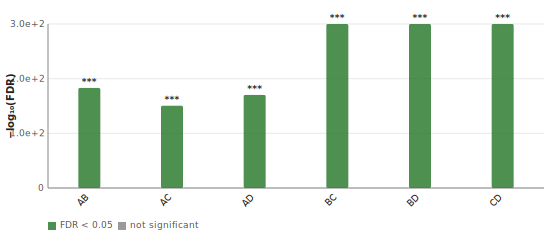

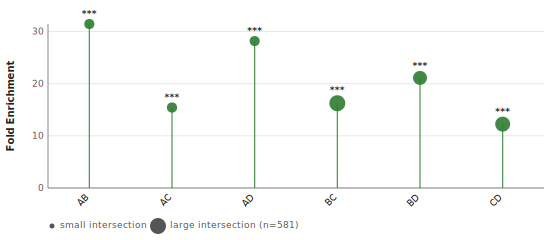

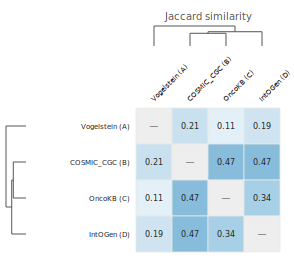

In [9]:
from venn_diagram_lab.render.svg import (
    render_cluster_heatmap_svg,
    render_enrichment_bar_svg,
    render_enrichment_lollipop_svg,
)

display(render_enrichment_bar_svg(result))
display(render_enrichment_lollipop_svg(result, metric='foldEnrichment'))
display(render_cluster_heatmap_svg(result, linkage='average'))

## Reproducing the web tool's TSV export

In [10]:
# The web tool's 'Export TSV' button produces a tab-separated table.
# Reproduce it in one line (print instead of saving to disk):
print(result.statistics.hypergeometric.to_csv(sep='\t', index=False))

set_a	set_b	intersection	expected	p_value	p_adjusted	significant	highly_significant
COSMIC_CGC	OncoKB	581	35.76055	0.0	0.0	True	True
COSMIC_CGC	IntOGen	388	18.38865	0.0	0.0	True	True
OncoKB	IntOGen	477	38.96115	0.0	0.0	True	True
Vogelstein	COSMIC_CGC	126	4.0089	6.751533818529152e-184	1.0127300727793728e-183	True	True
Vogelstein	IntOGen	123	4.3677	4.613516584500557e-171	5.536219901400668e-171	True	True
Vogelstein	OncoKB	131	8.4939	3.131044633644111e-151	3.131044633644111e-151	True	True



## Next steps

- [`07_pdf_reports.ipynb`](07_pdf_reports.ipynb) -- bundle Venn, UpSet, Network, and statistics into a single PDF report
- [`08_custom_styling_and_export.ipynb`](08_custom_styling_and_export.ipynb) -- style diagrams and export SVG/PNG for publication
